In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

x,y = make_classification(
    n_samples=1000, 
    n_features=20, 
    n_informative=12, 
    n_redundant=5, 
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.2, 
    random_state=42
)

In [11]:
base_estimator=[
    ('rf', RandomForestClassifier(
            n_estimators=100, 
            random_state=42
        )
    ),
    ('lgb', lgb.LGBMClassifier(
            n_estimators=100, 
            random_state=42
    )
    ),
    ('svc', make_pipeline(
            StandardScaler(), 
            SVC(
                kernel='rbf',
                probability=True, 
                random_state=42
            )
        )
    ),
]

stacking_clf=StackingClassifier(
    estimators=base_estimator, 
    final_estimator=LogisticRegression(random_state=42),
    cv=5,
    n_jobs=-1
)
stacking_clf.fit(X_train, y_train)


print("--- Stacking Ensemble Benchmark ---")
print(f"Individual RF Accuracy  : {stacking_clf.named_estimators_['rf'].score(X_test, y_test)*100:.2f}%")
print(f"Individual LGB Accuracy : {stacking_clf.named_estimators_['lgb'].score(X_test, y_test)*100:.2f}%")
print(f"Stacked Meta-Model Acc  : {stacking_clf.score(X_test, y_test)*100:.2f}%")

--- Stacking Ensemble Benchmark ---
Individual RF Accuracy  : 91.00%


c:\Users\Ayush\miniconda3\envs\Purva_Patole\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Individual LGB Accuracy : 92.50%
Stacked Meta-Model Acc  : 94.00%


c:\Users\Ayush\miniconda3\envs\Purva_Patole\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


c:\Users\Ayush\miniconda3\envs\Purva_Patole\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Ayush\miniconda3\envs\Purva_Patole\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


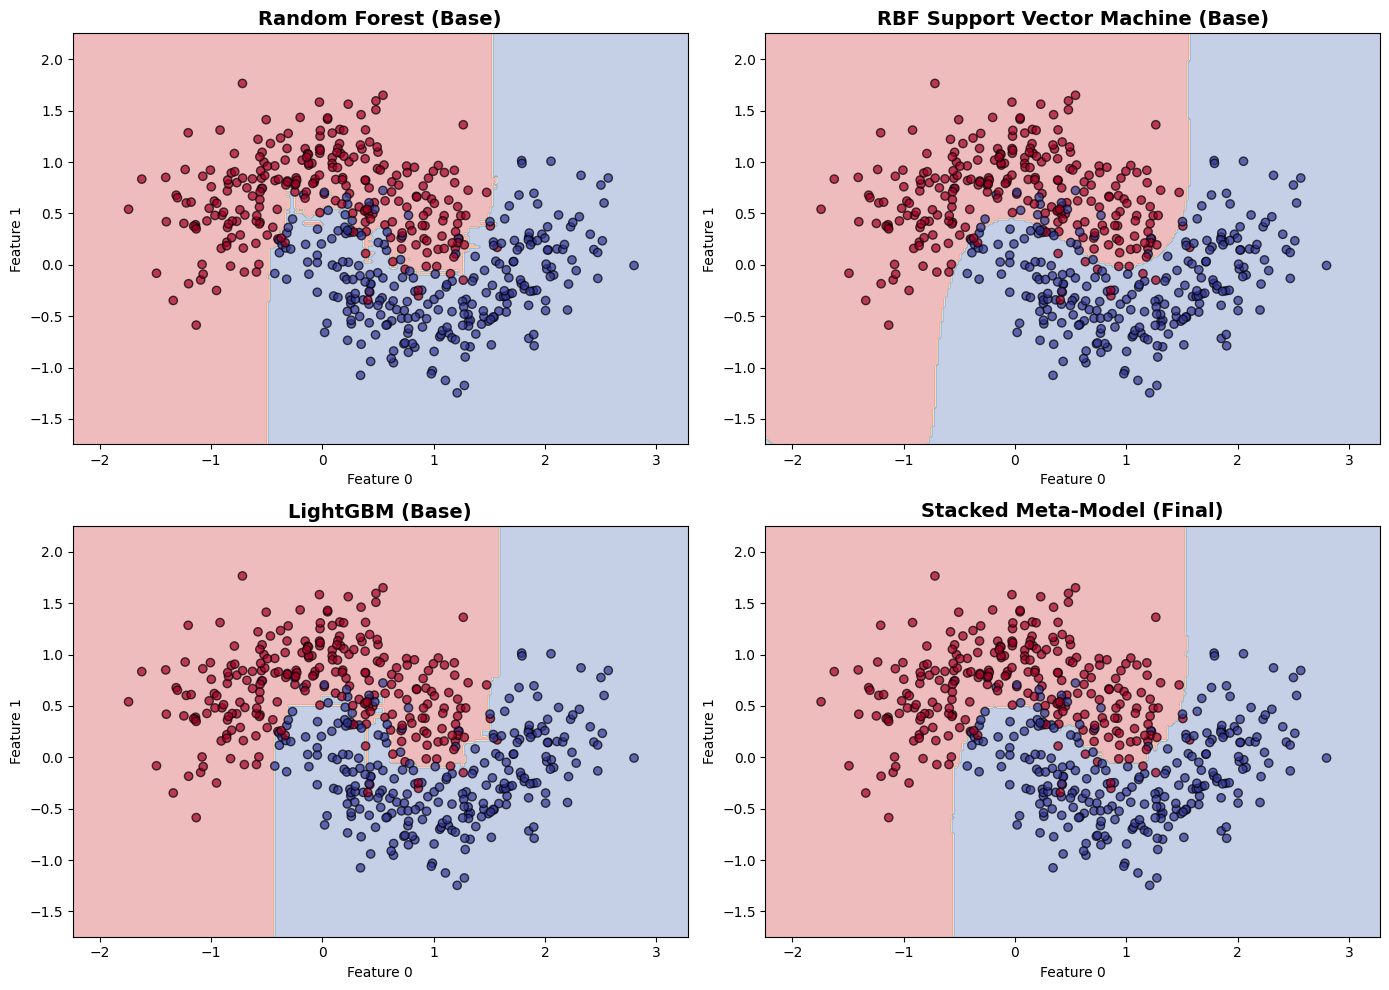

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)


base_models = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('svc', SVC(kernel="rbf", probability=True, random_state=42)),
    ('lgb', lgb.LGBMClassifier(n_estimators=50, random_state=42, verbose=-1))
]

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)
stacking_clf.fit(X, y)

models_dict = {
    "Random Forest (Base)": stacking_clf.named_estimators_['rf'],
    "RBF Support Vector Machine (Base)": stacking_clf.named_estimators_['svc'],
    "LightGBM (Base)": stacking_clf.named_estimators_['lgb'],
    "Stacked Meta-Model (Final)": stacking_clf
}

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(models_dict.items()):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    
    scatter = axes[idx].scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', alpha=0.7, cmap=plt.cm.RdYlBu)
    
    axes[idx].set_title(name, fontsize=14, fontweight='bold')
    axes[idx].set_xlabel("Feature 0")
    axes[idx].set_ylabel("Feature 1")

plt.tight_layout()
plt.show()